# Experiment 8: Quasi-Causal Job Title Premiums

**Research question:** Relative to `Data Scientist`, which normalized job-title groups are associated with higher or lower salary under comparable conditions?

**Design summary:** This notebook keeps the same unified dataset and salary parsing pipeline as the earlier experiments, but replaces skill-as-treatment with title-group comparisons. Raw titles are cleaned, mapped into title families, and then optionally split into seniority-aware hybrid groups when there is enough support.

**Why this experiment matters:** Raw title salary gaps can reflect dataset source, seniority, remote status, and overall skill breadth. Matching and fixed effects make the comparisons more comparable before estimating an adjusted title premium.

**Important caution:** This remains observational job-posting data. The estimates are quasi-causal / causal-style under strong assumptions, not proof that changing titles alone will cause the same salary change for an individual.

In [25]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from helpers import SKILL_PATTERNS, parse_salary
from job_dataset_union import build_unified_jobs_df

In [26]:
BASELINE_TITLE_FAMILY = "Data Scientist"

TOP_N_SKILL_CONTROLS = 8

MIN_TITLE_SUPPORT = 30                  # 30
MIN_MATCHED_TREATMENT_SUPPORT = 10      # 15 

MIN_SALARY_USD = 30_000
MAX_SALARY_USD = 400_000

INVALID_TITLE_VALUES = {"", "-1", "n/a", "na", "none", "null"}
ENTRY_PATTERN = r"\b(?:intern|internship|junior|jr\.?|entry[- ]level|graduate|new grad|associate)\b"
SENIOR_PATTERN = r"\b(?:senior|sr\.?|lead|principal|staff|manager|head|director|vice president|vp\b|chief)\b"

TITLE_FAMILY_PATTERNS = [
    ("VP/Vice President", r"\b(vice president|vp\b|svp\b|avp\b)\b"),
    ("Director", r"\bdirector\b"),
    ("Manager/Head", r"\b(manager|head|chief)\b"),
    ("Intern/Graduate", r"\b(intern|internship|co-op|coop|graduate|college graduate|new grad|grads)\b"),
    ("Consultant", r"\bconsultant\b"),
    ("Architect", r"\barchitect\b"),
    ("Software Engineer", r"\bsoftware engineer\b|\bdata software engineer\b"),
    ("NLP/LLM Specialist", r"\b(nlp engineer|nlp scientist|natural language processing|llm engineer|llm scientist|language model engineer|language model scientist|generative ai engineer|generative ai scientist|prompt engineer)\b"),
    ("MLOps Engineer", r"\b(mlops engineer|machine learning ops engineer|machine learning operations engineer|model deployment engineer|model serving engineer)\b"),
    ("Visualization/Reporting", r"\b(power bi developer|tableau developer|report developer|reporting developer|visualization engineer|data visualization specialist|bi developer|dashboard developer)\b"),
    ("Scientist", r"\b(machine learning scientist|bioinformatics scientist|associate scientist|scientist i\b|scientist ii\b|scientist iii\b|scientist iv\b|sleep medicine scientist)\b"),
    ("Specialist", r"\b(data specialist|analytics specialist|specialist solutions architect)\b"),
    ("Analytics Engineer", r"\b(analytics engineer|decision engineer|data analysis engineer)\b"),
    ("Database/Admin", r"\b(database administrator|database admin|dba|sql dba|database engineer)\b"),
    ("Data Engineer", r"\b(data engineer|data eng|sr data eng|analytics data engineer|data platform engineer|data warehouse engineer|etl engineer|elt engineer|pipeline engineer|etl developer|hadoop developer|data developer)\b"),
    ("ML/AI Engineer", r"\b(machine learning engineer|ml engineer|ai engineer|artificial intelligence engineer|ai/ml engineer|ml/ai engineer|ai / ml engineer|ai-ml engineer|computer vision engineer|deep learning engineer)\b"),
    ("Analyst/BI", r"\b(data analyst|business analyst|business intelligence analyst|bi analyst|market data analyst|analytics analyst|reporting analyst|data science analyst)\b"),
    ("Data Scientist", r"\b(data scientist|decision scientist|applied scientist|research scientist|ai data scientist|analytics scientist|data science)\b"),
]


def normalize_title_text(title):
    if pd.isna(title):
        return pd.NA

    title = str(title).strip().lower()
    title = title.replace("\u2013", "-").replace("\u2014", "-")
    title = title.replace("/", " / ")
    title = re.sub(r"^\s*(remote|hybrid|on[- ]site)\s*[-:]\s*", "", title)
    title = re.sub(r"\s*[-:]\s*(remote|hybrid|on[- ]site)\s*$", "", title)
    title = re.sub(r"\s+", " ", title).strip(" -")

    if not title or title in INVALID_TITLE_VALUES:
        return pd.NA
    return title


def assign_seniority_bucket(title):
    title = str(title).lower()
    entry_mask = bool(re.search(ENTRY_PATTERN, title))
    senior_mask = bool(re.search(SENIOR_PATTERN, title))

    if entry_mask and not senior_mask:
        return "entry_level"
    if senior_mask and not entry_mask:
        return "senior_plus"
    return "mid_level"


def assign_title_family(title):
    title = str(title).lower()
    for family, pattern in TITLE_FAMILY_PATTERNS:
        if re.search(pattern, title):
            return family
    return "Other"


def make_hybrid_title_group(title_family, seniority_bucket):
    if pd.isna(title_family) or title_family == "Other":
        return pd.NA
    if title_family == BASELINE_TITLE_FAMILY and seniority_bucket == "mid_level":
        return BASELINE_TITLE_FAMILY
    if seniority_bucket == "entry_level":
        return f"ENTRY-LEVEL: {title_family}"
    if seniority_bucket == "senior_plus":
        return f"SENIOR+: {title_family}"
    return title_family


def coarsen_skill_count(count):
    count = int(count)
    if count <= 2:
        return "1-2"
    if count <= 4:
        return "3-4"
    if count <= 6:
        return "5-6"
    return "7+"


def make_control_column_name(skill_name):
    safe_name = re.sub(r"[^0-9a-z]+", "_", skill_name.lower()).strip("_")
    return f"ctrl_skill_{safe_name}"


def fit_ols_hc3(y, X):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    xtx_inv = np.linalg.pinv(X.T @ X)
    beta = xtx_inv @ (X.T @ y)
    residuals = y - X @ beta
    leverage = np.sum((X @ xtx_inv) * X, axis=1)

    hc3_scale = (residuals / np.clip(1 - leverage, 1e-8, None)) ** 2
    meat = X.T @ (X * hc3_scale[:, None])
    covariance = xtx_inv @ meat @ xtx_inv

    standard_errors = np.sqrt(np.clip(np.diag(covariance), 0, None))
    z_statistics = beta / np.where(standard_errors == 0, np.nan, standard_errors)
    p_values = 2 * stats.norm.sf(np.abs(z_statistics))
    return beta, standard_errors, p_values


def log_beta_to_percent(beta):
    return (np.exp(beta) - 1) * 100

In [27]:
df = build_unified_jobs_df().copy()

df["salary_usd"] = df["salary_range"].apply(parse_salary)
salary_parse_summary = df.groupby("source_dataset").agg(
    total_jobs=("source_dataset", "size"),
    salary_not_parsed=("salary_usd", lambda s: s.isna().sum()),
)
salary_parse_summary["salary_not_parsed_share_pct"] = (
    salary_parse_summary["salary_not_parsed"] / salary_parse_summary["total_jobs"] * 100
)
df["title_raw"] = df["job_title"].fillna("").astype(str)
df["title_text"] = df["title_raw"].apply(normalize_title_text)
df["location_text"] = df["location"].fillna("").astype(str)
df["title_family"] = df["title_text"].apply(assign_title_family)
df["seniority_bucket"] = df["title_text"].apply(assign_seniority_bucket)

analysis_pool = df[df["salary_usd"].between(MIN_SALARY_USD, MAX_SALARY_USD)].copy()
analysis_pool = analysis_pool[analysis_pool["title_text"].notna()].copy()
analysis_pool = analysis_pool[
    analysis_pool["job_description_skills"].fillna("").astype(str).str.strip() != ""
].copy()

uncovered_title_count = int((analysis_pool["title_family"] == "Other").sum())
uncovered_title_share = uncovered_title_count / len(analysis_pool) * 100 if len(analysis_pool) else 0.0

analysis_df = analysis_pool[analysis_pool["title_family"] != "Other"].copy()

remote_text = analysis_df["location_text"].str.lower()
if "workType" in analysis_df.columns:
    remote_text = remote_text + " " + analysis_df["workType"].fillna("").astype(str).str.lower()
analysis_df["is_remote"] = remote_text.str.contains(r"\bremote\b", regex=True)

skill_flags = pd.DataFrame(
    {
        skill: analysis_df["job_description_skills"].fillna("").astype(str).str.contains(pattern, case=False, regex=True)
        for skill, pattern in SKILL_PATTERNS.items()
    },
    index=analysis_df.index,
)

analysis_df["matched_skill_count"] = skill_flags.sum(axis=1)
analysis_df = analysis_df[analysis_df["matched_skill_count"] > 0].copy()
skill_flags = skill_flags.loc[analysis_df.index].copy()
analysis_df["log_salary"] = np.log(analysis_df["salary_usd"])
analysis_df["skill_count_bin"] = analysis_df["matched_skill_count"].apply(coarsen_skill_count)

top_skill_controls = skill_flags.sum().sort_values(ascending=False).head(TOP_N_SKILL_CONTROLS).index.tolist()
control_rename_map = {skill: make_control_column_name(skill) for skill in top_skill_controls}
analysis_df = analysis_df.join(skill_flags[top_skill_controls].astype(float).rename(columns=control_rename_map))
control_cols = list(control_rename_map.values())

analysis_df["title_group_provisional"] = analysis_df.apply(
    lambda row: make_hybrid_title_group(row["title_family"], row["seniority_bucket"]),
    axis=1,
)

provisional_counts = analysis_df["title_group_provisional"].value_counts()
analysis_df["title_group"] = np.where(
    analysis_df["title_group_provisional"].map(provisional_counts).fillna(0) >= MIN_TITLE_SUPPORT,
    analysis_df["title_group_provisional"],
    analysis_df["title_family"],
)

final_title_counts = analysis_df["title_group"].value_counts()
analysis_df = analysis_df[analysis_df["title_group"].map(final_title_counts) >= MIN_TITLE_SUPPORT].copy()
final_title_counts = analysis_df["title_group"].value_counts()

print(f"Unified rows loaded: {len(df)}")
print(f"Rows after title/salary/skill filters: {len(analysis_df)}")
print(f"Median salary in analysis sample: ${analysis_df['salary_usd'].median():,.0f}")
print(f"Baseline Data Scientist family support: {(analysis_df['title_family'] == BASELINE_TITLE_FAMILY).sum()}")
print(f"Titles not covered by any family before dropping Other: {uncovered_title_count} ({uncovered_title_share:.1f}%)")
print()

print("Source breakdown:")
print(analysis_df["source_dataset"].value_counts().to_string())
print()

print("Salary parse failures by source (full unified data):")
print(
    salary_parse_summary.to_string(
        formatters={"salary_not_parsed_share_pct": lambda value: f"{value:.1f}%"}
    )
)
print()

print("Title-group breakdown (top 15):")
print(final_title_counts.head(15).to_string())
print()

print("Top skill controls used only for residual adjustment:")
print(pd.Series(top_skill_controls, index=range(1, len(top_skill_controls) + 1)).to_string())

Unified rows loaded: 36845
Rows after title/salary/skill filters: 3064
Median salary in analysis sample: $132,704
Baseline Data Scientist family support: 1246
Titles not covered by any family before dropping Other: 659 (13.8%)

Source breakdown:
source_dataset
our_own_dataset                1849
data_science_job_posts_2025     691
glassdoor_2023                  524

Salary parse failures by source (full unified data):
                             total_jobs  salary_not_parsed salary_not_parsed_share_pct
source_dataset                                                                        
data_science_job_posts_2025         944                  0                        0.0%
glassdoor_2023                     1500                375                       25.0%
our_own_dataset                   34401              30531                       88.8%

Title-group breakdown (top 15):
title_group
Data Scientist                  1066
SENIOR+: Director                238
Data Engineer          

In [28]:
final_title_counts.head(40)

title_group
Data Scientist                  1066
SENIOR+: Director                238
Data Engineer                    227
ML/AI Engineer                   207
Analyst/BI                       199
SENIOR+: Manager/Head            191
SENIOR+: Data Scientist          180
SENIOR+: VP/Vice President       145
Software Engineer                138
SENIOR+: Data Engineer           101
Architect                         82
ENTRY-LEVEL: Intern/Graduate      68
SENIOR+: ML/AI Engineer           67
SENIOR+: Analyst/BI               50
SENIOR+: Software Engineer        40
Analytics Engineer                34
SENIOR+: Database/Admin           31
Name: count, dtype: int64

## Matched Fixed-Effects Title Comparisons

For each eligible title group outside the `Data Scientist` family, we compare that group against a `Data Scientist` baseline inside matched strata defined by:

- `is_remote`
- `seniority_bucket`
- coarsened `matched_skill_count`

Only strata that contain both the treatment title group and the `Data Scientist` baseline are kept. Inside that matched sample, we run OLS on `log_salary` with:

- a treatment indicator for the focal title group
- stratum fixed effects
- continuous `matched_skill_count`
- the top 8 most-supported skill flags as controls only

This is stronger than a raw correlation, but it still relies on observational assumptions and should be described as quasi-causal or causal-style, not fully causal.

In [29]:
baseline_median_salary_usd = analysis_df.loc[
    analysis_df["title_group"] == BASELINE_TITLE_FAMILY,
    "salary_usd",
].median()

results = []

eligible_title_groups = []
for title_group, support in final_title_counts.items():
    family_mode = analysis_df.loc[analysis_df["title_group"] == title_group, "title_family"].mode()
    if family_mode.empty:
        continue
    if family_mode.iat[0] == BASELINE_TITLE_FAMILY:
        continue
    eligible_title_groups.append(title_group)

for title_group in eligible_title_groups:
    target_mask = analysis_df["title_group"] == title_group
    raw_support = int(target_mask.sum())
    target_family = analysis_df.loc[target_mask, "title_family"].mode().iat[0]

    compare_df = analysis_df.loc[target_mask | (analysis_df["title_family"] == BASELINE_TITLE_FAMILY)].copy()
    compare_df["is_treatment"] = (compare_df["title_group"] == title_group).astype(float)
    compare_df["stratum_key"] = (
        "remote=" + compare_df["is_remote"].astype(int).astype(str)
        + " | seniority=" + compare_df["seniority_bucket"].astype(str)
        + " | skill_bin=" + compare_df["skill_count_bin"].astype(str)
    )

    stratum_class_counts = compare_df.groupby("stratum_key")["is_treatment"].nunique()
    valid_strata = stratum_class_counts[stratum_class_counts == 2].index
    matched_df = compare_df[compare_df["stratum_key"].isin(valid_strata)].copy()

    matched_support = int(matched_df["is_treatment"].sum()) 

    baseline_matched_support = int((matched_df["is_treatment"] == 0).sum())
    matched_strata = int(matched_df["stratum_key"].nunique())

    if matched_support < MIN_MATCHED_TREATMENT_SUPPORT:
        continue
    if baseline_matched_support < MIN_MATCHED_TREATMENT_SUPPORT:
        continue

    X = pd.DataFrame(
        {
            "const": 1.0,
            "is_treatment": matched_df["is_treatment"].astype(float),
            "matched_skill_count": matched_df["matched_skill_count"].astype(float),
        },
        index=matched_df.index,
    )
    X = pd.concat(
        [
            X,
            matched_df[control_cols].astype(float),
            pd.get_dummies(matched_df["stratum_key"], prefix="stratum", drop_first=True, dtype=float),
        ],
        axis=1,
    )

    beta, standard_errors, p_values = fit_ols_hc3(matched_df["log_salary"].to_numpy(), X.to_numpy())
    coef_idx = X.columns.get_loc("is_treatment")
    title_beta = beta[coef_idx]
    adjusted_premium_pct = log_beta_to_percent(title_beta)

    target_salary = analysis_df.loc[target_mask, "salary_usd"]
    median_treatment_salary = target_salary.median()
    descriptive_salary_delta_usd = median_treatment_salary - baseline_median_salary_usd
    descriptive_premium_pct = descriptive_salary_delta_usd / baseline_median_salary_usd * 100

    mean_treatment_salary = target_salary.mean()

    results.append(
        {
            "title_group": title_group,
            "title_family": target_family,
            "raw_support": raw_support,
            "share_pct": raw_support / len(analysis_df) * 100,
            "matched_support": matched_support,
            "baseline_matched_support": baseline_matched_support,
            "matched_strata": matched_strata,
            "premium_pct": descriptive_premium_pct,
            "approx_salary_delta_usd": descriptive_salary_delta_usd,
            "median_treatment_salary": median_treatment_salary,
            "adjusted_premium_pct": adjusted_premium_pct,
            "adjusted_salary_delta_usd": baseline_median_salary_usd * (adjusted_premium_pct / 100),
            "coef_log_salary": title_beta,
            "std_error": standard_errors[coef_idx],
            "p_value": p_values[coef_idx],
            "mean_treatment_salary": mean_treatment_salary,
            "baseline_median_salary_usd": baseline_median_salary_usd,
            "salary_gap_vs_baseline_median_usd": mean_treatment_salary - baseline_median_salary_usd,
        }
    )

results_df = pd.DataFrame(results).sort_values(
    ["premium_pct", "matched_support"],
    ascending=[False, False],
).reset_index(drop=True)

results_df["significant_5pct"] = results_df["p_value"] < 0.05 

print("Descriptive title ranking relative to the Data Scientist median baseline:")
if results_df.empty:
    print("No eligible title groups produced a matched estimate under the current support thresholds.")
else:
    print(
        results_df[
            [
                "title_group",
                "title_family",
                "raw_support",
                "median_treatment_salary",
                "baseline_median_salary_usd",
                "premium_pct",
                "approx_salary_delta_usd",
                "adjusted_premium_pct",
                "p_value",
            ]
        ].head(15).to_string(index=False)
    )

Descriptive title ranking relative to the Data Scientist median baseline:
                 title_group       title_family  raw_support  median_treatment_salary  baseline_median_salary_usd  premium_pct  approx_salary_delta_usd  adjusted_premium_pct      p_value
  SENIOR+: VP/Vice President  VP/Vice President          145               190000.000                    126000.0    50.793651                64000.000             34.959753 2.554983e-18
           SENIOR+: Director           Director          238               185000.000                    126000.0    46.825397                59000.000             39.456119 1.089248e-20
     SENIOR+: ML/AI Engineer     ML/AI Engineer           67               167000.000                    126000.0    32.539683                41000.000              3.509293 5.248428e-01
                   Architect          Architect           82               162500.000                    126000.0    28.968254                36500.000             28.344935 1.87

In [30]:
positive_titles = results_df[results_df["premium_pct"] > 0] if not results_df.empty else pd.DataFrame()
negative_titles = results_df[results_df["premium_pct"] < 0] if not results_df.empty else pd.DataFrame()

print("Top positive descriptive title premiums vs Data Scientist median:")
if positive_titles.empty:
    print("No title groups have a positive median premium.")
else:
    print(
        positive_titles[
            [
                "title_group",
                "raw_support",
                "median_treatment_salary",
                "premium_pct",
                "approx_salary_delta_usd",
                "adjusted_premium_pct",
            ]
        ].head(10).to_string(index=False)
    )

print("\nTop negative descriptive title premiums vs Data Scientist median:")
if negative_titles.empty:
    print("No title groups have a negative median premium.")
else:
    print(
        negative_titles[
            [
                "title_group",
                "raw_support",
                "median_treatment_salary",
                "premium_pct",
                "approx_salary_delta_usd",
                "adjusted_premium_pct",
            ]
        ].head(10).to_string(index=False)
    )

print("\nCompact ranking table:")
if results_df.empty:
    print("No results to display.")
else:
    print(
        results_df[
            [
                "title_group",
                "title_family",
                "raw_support",
                "median_treatment_salary",
                "premium_pct",
                "approx_salary_delta_usd",
                "adjusted_premium_pct",
            ]
        ].head(20).to_string(index=False)
    )

Top positive descriptive title premiums vs Data Scientist median:
               title_group  raw_support  median_treatment_salary  premium_pct  approx_salary_delta_usd  adjusted_premium_pct
SENIOR+: VP/Vice President          145               190000.000    50.793651                64000.000             34.959753
         SENIOR+: Director          238               185000.000    46.825397                59000.000             39.456119
   SENIOR+: ML/AI Engineer           67               167000.000    32.539683                41000.000              3.509293
                 Architect           82               162500.000    28.968254                36500.000             28.344935
SENIOR+: Software Engineer           40               162500.000    28.968254                36500.000             13.030285
    SENIOR+: Data Engineer          101               153600.000    21.904762                27600.000              2.456616
            ML/AI Engineer          207               15000

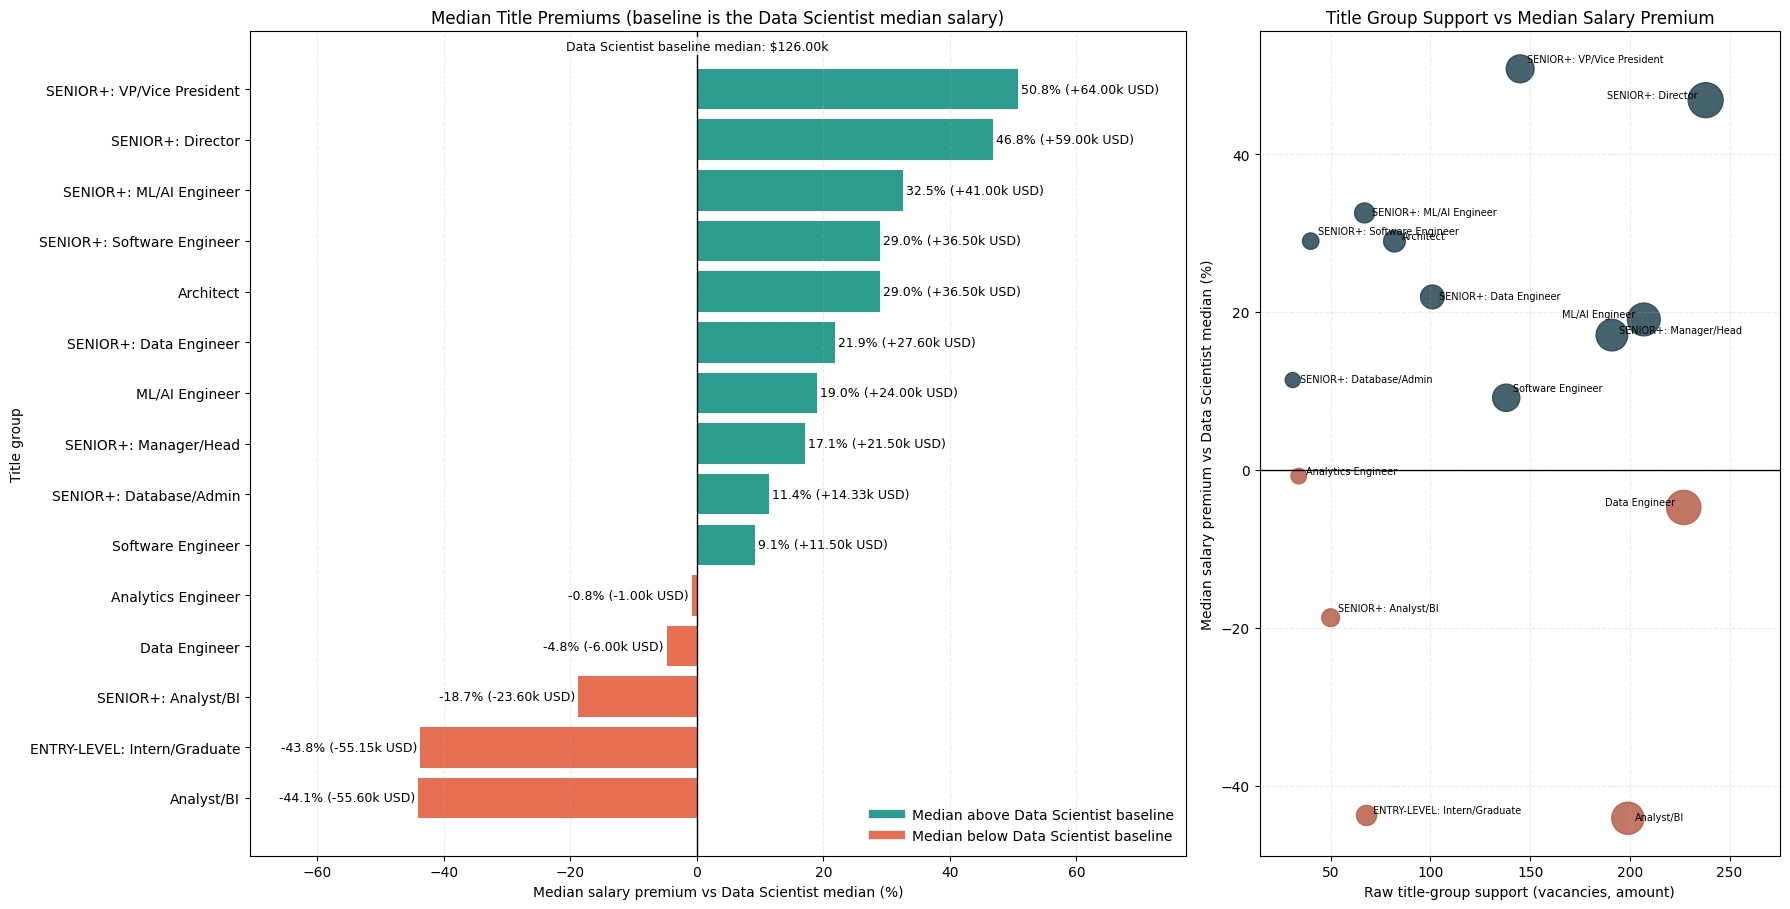

In [31]:
if results_df.empty:
    print("No title-premium estimates available to plot.")
else:
    baseline_median_salary_usd = analysis_df.loc[
        analysis_df["title_group"] == BASELINE_TITLE_FAMILY,
        "salary_usd",
    ].median()
    plot_df = results_df.sort_values("premium_pct").copy()
    plot_df["premium_delta_k_usd"] = baseline_median_salary_usd * plot_df["premium_pct"] / 100 / 1000
    plot_df["bar_color"] = np.where(plot_df["premium_pct"] >= 0, "#2a9d8f", "#e76f51")
    plot_df["label_text"] = plot_df.apply(
        lambda row: f"{row['premium_pct']:.1f}% ({row['premium_delta_k_usd']:+.2f}k USD)",
        axis=1,
    )

    fig_height = max(7, 0.48 * len(plot_df) + 2)
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, fig_height),
        gridspec_kw={"width_ratios": [1.8, 1.0]},
    )

    axes[0].barh(plot_df["title_group"], plot_df["premium_pct"], color=plot_df["bar_color"])
    premium_min = min(0, plot_df["premium_pct"].min())
    premium_max = max(0, plot_df["premium_pct"].max())
    premium_span = max(premium_max - premium_min, 1)
    label_margin = max(12.0, premium_span * 0.28)
    axes[0].set_xlim(premium_min - label_margin, premium_max + label_margin)
    for idx, row in enumerate(plot_df.itertuples(index=False)):
        text_offset = 0.45 if row.premium_pct >= 0 else -0.45
        ha = "left" if row.premium_pct >= 0 else "right"
        axes[0].text(
            row.premium_pct + text_offset,
            idx,
            row.label_text,
            va="center",
            ha=ha,
            fontsize=9,
            clip_on=False,
        )
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].text(
        0,
        0.99,
        f"Data Scientist baseline median: ${baseline_median_salary_usd / 1000:.2f}k",
        transform=axes[0].get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 2},
    )
    axes[0].grid(axis="x", linestyle="--", alpha=0.25)
    axes[0].set_title("Median Title Premiums (baseline is the Data Scientist median salary)")
    axes[0].set_xlabel("Median salary premium vs Data Scientist median (%)")
    axes[0].set_ylabel("Title group")

    scatter_colors = np.where(plot_df["premium_pct"] >= 0, "#264653", "#b85f49")
    scatter_sizes = 40 + plot_df["raw_support"].to_numpy() * 2.5
    axes[1].scatter(
        plot_df["raw_support"],
        plot_df["premium_pct"],
        s=scatter_sizes,
        c=scatter_colors,
        alpha=0.85,
    )
    support_min = plot_df["raw_support"].min()
    support_max = plot_df["raw_support"].max()
    support_span = max(support_max - support_min, 1)
    axes[1].set_xlim(support_min - support_span * 0.08, support_max + support_span * 0.18)
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].grid(axis="both", linestyle="--", alpha=0.25)
    axes[1].set_title("Title Group Support vs Median Salary Premium")
    axes[1].set_xlabel("Raw title-group support (vacancies, amount)")
    axes[1].set_ylabel("Median salary premium vs Data Scientist median (%)")

    right_label_threshold = support_min + support_span * 0.82
    for idx, row in plot_df.reset_index(drop=True).iterrows():
        near_right_edge = row["raw_support"] >= right_label_threshold
        text_offset = (-6, 4) if near_right_edge else (5, 4 + (idx % 3 - 1) * 3)
        horizontal_align = "right" if near_right_edge else "left"
        axes[1].annotate(
            row["title_group"],
            (row["raw_support"], row["premium_pct"]),
            fontsize=7,
            xytext=text_offset,
            textcoords="offset points",
            ha=horizontal_align,
            va="center",
            clip_on=False,
        )

    legend_lines = [
        plt.Line2D([0], [0], color="#2a9d8f", lw=6, label="Median above Data Scientist baseline"),
        plt.Line2D([0], [0], color="#e76f51", lw=6, label="Median below Data Scientist baseline"),
    ]
    axes[0].legend(handles=legend_lines, loc="lower right", frameon=False)

    plt.tight_layout()
    plt.show()

Regression-adjusted title premiums relative to matched Data Scientist comparisons:
                 title_group  matched_support  baseline_matched_support  matched_strata  adjusted_premium_pct  adjusted_salary_delta_usd      p_value  significant_5pct
           SENIOR+: Director              238                       180               5             39.456119               49714.709428 1.089248e-20              True
     SENIOR+: Database/Admin               31                       107               2             37.325279               47029.851607 9.337450e-02             False
  SENIOR+: VP/Vice President              145                       171               4             34.959753               44049.288632 2.554983e-18              True
              ML/AI Engineer              207                      1018               5             34.195159               43085.900579 1.575123e-13              True
                   Architect               82                      1202      

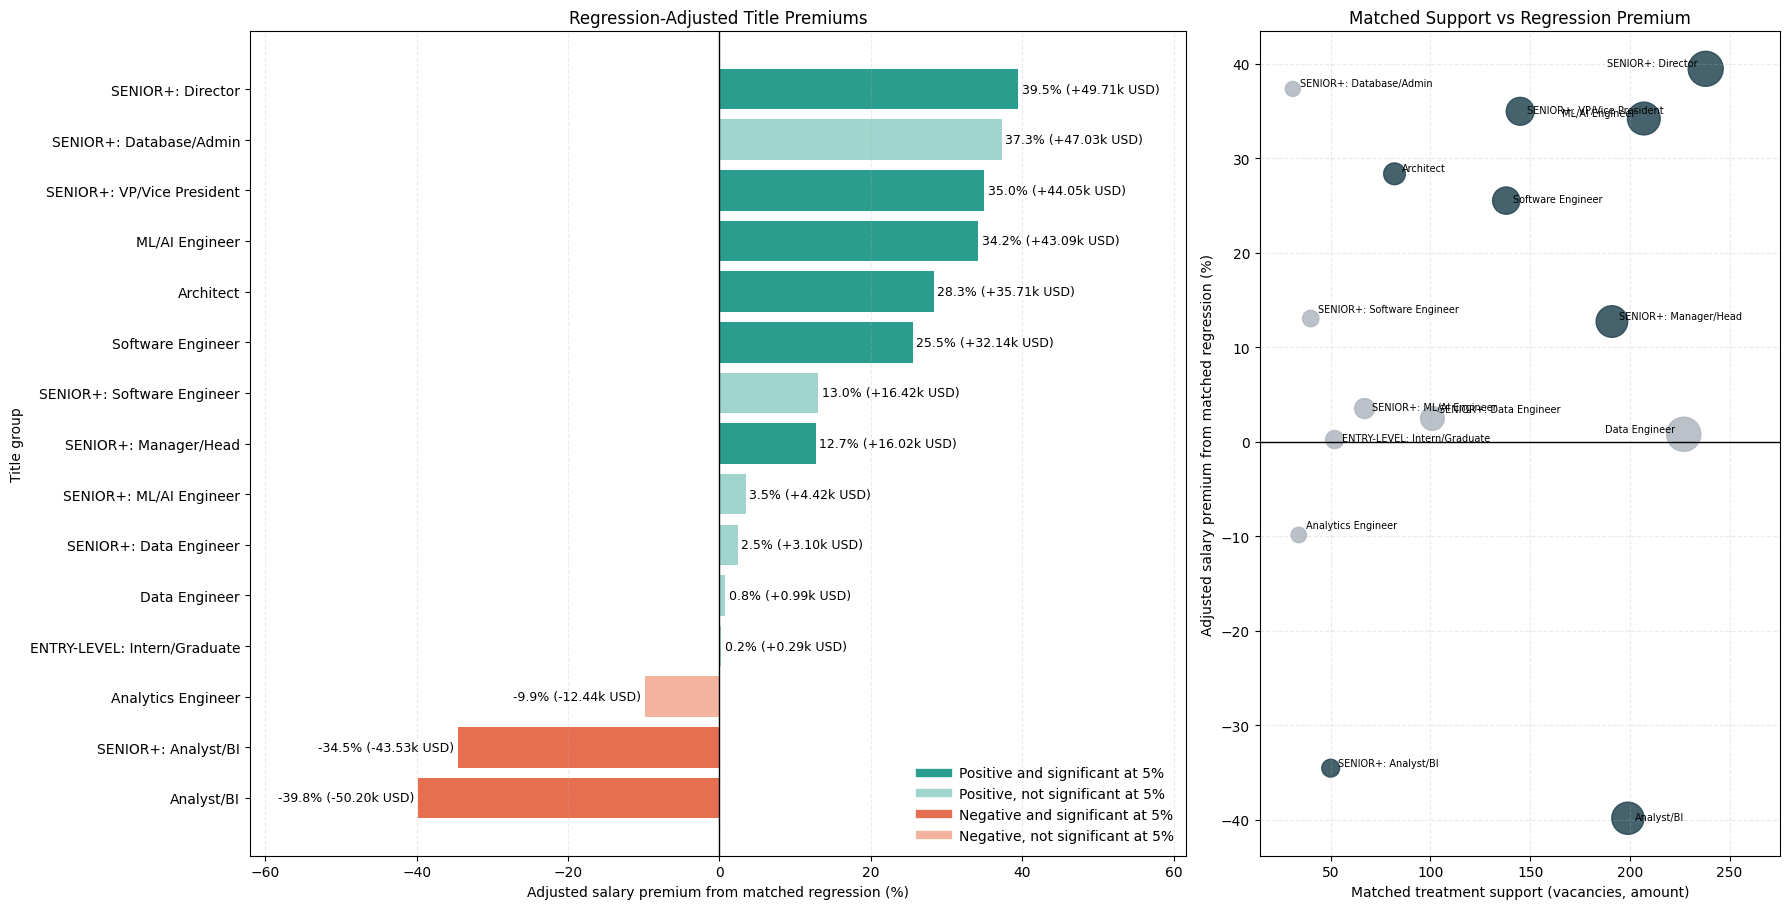

In [33]:
if results_df.empty:
    print("No regression title-premium estimates available to plot.")
else:
    regression_plot_df = results_df.sort_values("adjusted_premium_pct").copy()
    regression_plot_df["adjusted_delta_k_usd"] = regression_plot_df["adjusted_salary_delta_usd"] / 1000
    regression_plot_df["bar_color"] = np.select(
        [
            (regression_plot_df["adjusted_premium_pct"] >= 0) & regression_plot_df["significant_5pct"],
            (regression_plot_df["adjusted_premium_pct"] >= 0) & ~regression_plot_df["significant_5pct"],
            (regression_plot_df["adjusted_premium_pct"] < 0) & regression_plot_df["significant_5pct"],
        ],
        ["#2a9d8f", "#9fd5cc", "#e76f51"],
        default="#f3b39f",
    )
    regression_plot_df["label_text"] = regression_plot_df.apply(
        lambda row: f"{row['adjusted_premium_pct']:.1f}% ({row['adjusted_delta_k_usd']:+.2f}k USD)",
        axis=1,
    )

    print("Regression-adjusted title premiums relative to matched Data Scientist comparisons:")
    print(
        regression_plot_df[
            [
                "title_group",
                "matched_support",
                "baseline_matched_support",
                "matched_strata",
                "adjusted_premium_pct",
                "adjusted_salary_delta_usd",
                "p_value",
                "significant_5pct",
            ]
        ].sort_values("adjusted_premium_pct", ascending=False).to_string(index=False)
    )

    fig_height = max(7, 0.48 * len(regression_plot_df) + 2)
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, fig_height),
        gridspec_kw={"width_ratios": [1.8, 1.0]},
    )

    axes[0].barh(
        regression_plot_df["title_group"],
        regression_plot_df["adjusted_premium_pct"],
        color=regression_plot_df["bar_color"],
    )
    premium_min = min(0, regression_plot_df["adjusted_premium_pct"].min())
    premium_max = max(0, regression_plot_df["adjusted_premium_pct"].max())
    premium_span = max(premium_max - premium_min, 1)
    label_margin = max(12.0, premium_span * 0.28)
    axes[0].set_xlim(premium_min - label_margin, premium_max + label_margin)
    for idx, row in enumerate(regression_plot_df.itertuples(index=False)):
        text_offset = 0.45 if row.adjusted_premium_pct >= 0 else -0.45
        ha = "left" if row.adjusted_premium_pct >= 0 else "right"
        axes[0].text(
            row.adjusted_premium_pct + text_offset,
            idx,
            row.label_text,
            va="center",
            ha=ha,
            fontsize=9,
            clip_on=False,
        )
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].grid(axis="x", linestyle="--", alpha=0.25)
    axes[0].set_title("Regression-Adjusted Title Premiums")
    axes[0].set_xlabel("Adjusted salary premium from matched regression (%)")
    axes[0].set_ylabel("Title group")

    scatter_colors = np.where(regression_plot_df["significant_5pct"], "#264653", "#b0b7bf")
    scatter_sizes = 40 + regression_plot_df["matched_support"].to_numpy() * 2.5
    axes[1].scatter(
        regression_plot_df["matched_support"],
        regression_plot_df["adjusted_premium_pct"],
        s=scatter_sizes,
        c=scatter_colors,
        alpha=0.85,
    )
    support_min = regression_plot_df["matched_support"].min()
    support_max = regression_plot_df["matched_support"].max()
    support_span = max(support_max - support_min, 1)
    axes[1].set_xlim(support_min - support_span * 0.08, support_max + support_span * 0.18)
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].grid(axis="both", linestyle="--", alpha=0.25)
    axes[1].set_title("Matched Support vs Regression Premium")
    axes[1].set_xlabel("Matched treatment support (vacancies, amount)")
    axes[1].set_ylabel("Adjusted salary premium from matched regression (%)")

    right_label_threshold = support_min + support_span * 0.82
    for idx, row in regression_plot_df.reset_index(drop=True).iterrows():
        near_right_edge = row["matched_support"] >= right_label_threshold
        text_offset = (-6, 4) if near_right_edge else (5, 4 + (idx % 3 - 1) * 3)
        horizontal_align = "right" if near_right_edge else "left"
        axes[1].annotate(
            row["title_group"],
            (row["matched_support"], row["adjusted_premium_pct"]),
            fontsize=7,
            xytext=text_offset,
            textcoords="offset points",
            ha=horizontal_align,
            va="center",
            clip_on=False,
        )

    legend_lines = [
        plt.Line2D([0], [0], color="#2a9d8f", lw=6, label="Positive and significant at 5%"),
        plt.Line2D([0], [0], color="#9fd5cc", lw=6, label="Positive, not significant at 5%"),
        plt.Line2D([0], [0], color="#e76f51", lw=6, label="Negative and significant at 5%"),
        plt.Line2D([0], [0], color="#f3b39f", lw=6, label="Negative, not significant at 5%"),
    ]
    axes[0].legend(handles=legend_lines, loc="lower right", frameon=False)

    plt.tight_layout()
    plt.show()

## Outputs for report

* (1) Variable / Inputs: Dependent variable: log salary. The main independent variable is normalized job title group, measured relative to a Data Scientist baseline. Controls include remote status, seniority, matched skill count, and the top 8 skill indicators.

* (2) Model: Matched fixed-effects Ordinary Least Squares regression with HC3 robust standard errors, estimated separately for each eligible title group.

* (3) Finding Statement: Title groups were ranked by adjusted salary premium after controlling for observable job characteristics. Senior-Director (in data) roles showed the largest positive estimate (+13.7%) statistically significant comparing to data science roles. Data Engineer showed a negative estimate (-14%), also statistically significant. Analyst/BI exhibited a large and statistically significant negative premium (-35.87%, approximately -$39.5K) relative to Data Scientist.

* (4) Limitation or Extension: Results are based on observational job-posting data titles of positions. Title may reflect role scope and seniority, so results should be interpreted as quasi-causal.


## Validation checks

In [32]:
assert (analysis_df["title_family"] == BASELINE_TITLE_FAMILY).any(), "Baseline Data Scientist family is missing from the analysis sample."
assert not analysis_df["title_text"].isin(INVALID_TITLE_VALUES).any(), "Placeholder titles survived title cleaning."
if not results_df.empty:
    assert results_df["raw_support"].ge(MIN_TITLE_SUPPORT).all(), "A reported title group fell below MIN_TITLE_SUPPORT."
    assert results_df["matched_strata"].ge(1).all(), "Each estimate must retain at least one matched stratum."

print("Normalization examples:")
examples = analysis_df.loc[
    analysis_df["title_raw"].str.contains(
        r"data scientist|data engineer|business analyst|machine learning engineer|remote - data scientist",
        case=False,
        na=False,
        regex=True,
    ),
    ["title_raw", "title_text", "title_family", "seniority_bucket", "title_group"],
].drop_duplicates().head(15)
print(examples.to_string(index=False))
print()

print("Sanity-check family counts:")
for family in ["Data Engineer", "ML/AI Engineer", "Analyst/BI", "Data Scientist"]:
    print(f"{family}: {(analysis_df['title_family'] == family).sum()}")
print()

print("Validation summary:")
print(f"- Invalid placeholders removed: {not analysis_df['title_text'].isin(INVALID_TITLE_VALUES).any()}")
print(f"- Uncovered titles before dropping Other: {uncovered_title_count} ({uncovered_title_share:.1f}%)")
print(f"- Eligible title groups reported: {len(results_df)}")
print(f"- Minimum raw support enforced: {MIN_TITLE_SUPPORT}")
print(f"- Baseline family: {BASELINE_TITLE_FAMILY}")
print("- Matching dimensions: is_remote, seniority_bucket, skill_count_bin")

Normalization examples:
                                                               title_raw                                                               title_text    title_family seniority_bucket                  title_group
                               2024 University Graduate - Data Scientist                                2024 university graduate - data scientist Intern/Graduate      entry_level ENTRY-LEVEL: Intern/Graduate
                                       Data Scientist – Entry Level 2024                                        data scientist - entry level 2024  Data Scientist      entry_level               Data Scientist
                                                        Data Scientist 2                                                         data scientist 2  Data Scientist        mid_level               Data Scientist
                                                      Data Scientist (C)                                                       data scientist (c